<a href="https://colab.research.google.com/github/nehavaishnav/CEI_ASSIGNMENT/blob/main/CIFAR10_Complete_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIFAR-10 Classification — Complete Assignment Solution
### Covers all 8 tasks from the assignment spec

---
## Task 1 & 2 — Load CIFAR-10 & Normalize

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print('TensorFlow:', tf.__version__)

CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Task 1 — Load the standard CIFAR-10 classification database
# 50,000 training images + 10,000 evaluation images
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print(f'Training images : {x_train.shape}  → 50,000 images of 32×32×3')
print(f'Evaluation images: {x_test.shape}  → 10,000 images of 32×32×3')
print(f'Pixel range before normalization: [{x_train.min()}, {x_train.max()}]')

# Task 2 — Normalize raw image channel pixel integers (0–255 → 0.0–1.0)
# Dividing by 255 maps every pixel to [0, 1]
# This stabilizes gradient updates — without it, large activations cause
# exploding/vanishing gradients and slow/unstable training
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32')  / 255.0

print(f'Pixel range after normalization : [{x_train_norm.min():.1f}, {x_train_norm.max():.1f}]')

# Flatten for ANN (3072 = 32 × 32 × 3 — spatial structure is discarded)
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat  = x_test_norm.reshape(len(x_test_norm), -1)

print(f'\nANN input shape (flat) : {x_train_flat.shape}')
print(f'CNN input shape (3D)   : {x_train_norm.shape}')

TensorFlow: 2.20.0
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
Training images : (50000, 32, 32, 3)  → 50,000 images of 32×32×3
Evaluation images: (10000, 32, 32, 3)  → 10,000 images of 32×32×3
Pixel range before normalization: [0, 255]
Pixel range after normalization : [0.0, 1.0]

ANN input shape (flat) : (50000, 3072)
CNN input shape (3D)   : (50000, 32, 32, 3)


---
## Task 3 — Baseline ANN using Dense + Dropout layers

ANN receives a **flat vector** (3072 values). Spatial relationships between pixels are completely lost at the input stage — the model cannot learn that (5,5) and (5,6) are neighbors.

In [2]:
tf.random.set_seed(42)

ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='ANN_Baseline')

# Task 5 — Compile with Adam optimizer, sparse categorical cross-entropy
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

# Task 5 — Train for 10 epochs
ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

ann_loss, ann_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f'\nANN Test Accuracy : {ann_acc:.4f} ({ann_acc*100:.1f}%)')
print(f'ANN Test Loss     : {ann_loss:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "ANN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.2736 - loss: 1.9864 - val_accuracy: 0.3074 - val_loss: 1.8816
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.3157 - loss: 1.8640 - val_accuracy: 0.3624 - val_loss: 1.7804
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.3411 - loss: 1.8087 - val_accuracy: 0.3706 - val_loss: 1.7708
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.3535 - loss: 1.7726 - val_accuracy: 0.3728 - val_loss: 1.7425
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.3659 - loss: 1.7463 - val_accuracy: 0.3852 - val_loss: 1.7353
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.3714 - loss: 1.7279 - val_accuracy: 0.3894 - val_loss: 1.7111
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.3792 - loss: 1.7098 - val_accuracy: 0.3958 - val_loss: 1.6759
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.3831 - loss: 1.6984 - 

---
## Task 4 — Spatial CNN using Conv2D, BatchNormalization, MaxPooling2D, Flatten, Dense

CNN operates on the **full 32×32×3 tensor**. Convolutional filters slide over the spatial grid, learning local patterns (edges → textures → shapes) hierarchically.

In [3]:
tf.random.set_seed(42)

cnn_model = models.Sequential([
    # Block 1 — learns low-level edges
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),           # 32×32 → 16×16

    # Block 2 — learns mid-level textures
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),           # 16×16 → 8×8

    # Block 3 — learns high-level shapes
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    # Classifier head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_Spatial')

# Task 5 — Compile with Adam + sparse categorical cross-entropy
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

# Task 5 — Train for 10 epochs
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

cnn_loss, cnn_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f'\nCNN Test Accuracy : {cnn_acc:.4f} ({cnn_acc*100:.1f}%)')
print(f'CNN Test Loss     : {cnn_loss:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Spatial"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,144,138 (4.36 MB)

 Trainable params: 1,143,690 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 127s 176ms/step - accuracy: 0.4347 - loss: 1.6004 - val_accuracy: 0.5320 - val_loss: 1.3566
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 123s 174ms/step - accuracy: 0.5918 - loss: 1.1602 - val_accuracy: 0.6294 - val_loss: 1.0506
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 122s 173ms/step - accuracy: 0.6628 - loss: 0.9588 - val_accuracy: 0.6344 - val_loss: 1.0700
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 174ms/step - accuracy: 0.7116 - loss: 0.8198 - val_accuracy: 0.6780 - val_loss: 0.9624
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 122s 173ms/step - accuracy: 0.7483 - loss: 0.7100 - val_accuracy: 0.7362 - val_loss: 0.7851
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 120s 171ms/step - accuracy: 0.7831 - loss: 0.6128 - val_accuracy: 0.6812 - val_loss: 1.0718
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 124s 176ms/step - accuracy: 0.8092 - loss: 0.5352 - val_accuracy: 0.6862 - val_loss: 0.9845
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 122s 173ms/step - accuracy: 0.8347 -

---
## Task 6 — Plot validation accuracy tracking curves for both pipelines on a single chart

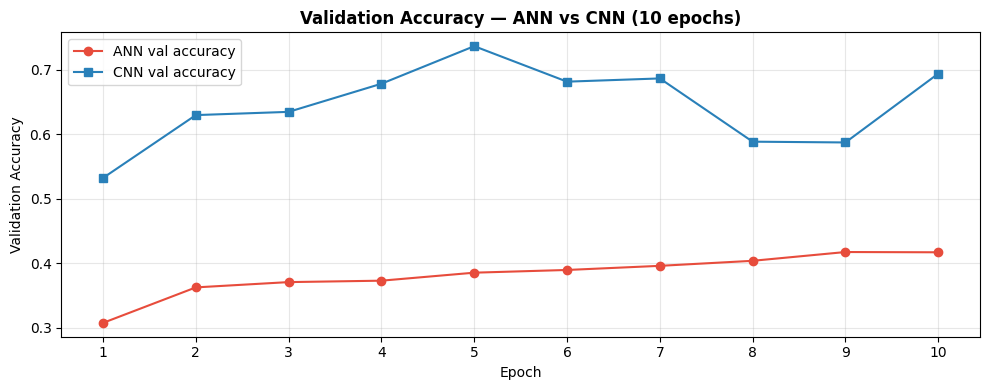

Final ANN val accuracy : 0.4168
Final CNN val accuracy : 0.6936
CNN advantage          : +27.7%


In [4]:
epochs_range = range(1, 11)

plt.figure(figsize=(10, 4))

plt.plot(epochs_range, ann_history.history['val_accuracy'],
         color='#e74c3c', marker='o', label='ANN val accuracy')
plt.plot(epochs_range, cnn_history.history['val_accuracy'],
         color='#2980b9', marker='s', label='CNN val accuracy')

plt.title('Validation Accuracy — ANN vs CNN (10 epochs)', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(epochs_range)
plt.tight_layout()
plt.show()

print(f'Final ANN val accuracy : {ann_history.history["val_accuracy"][-1]:.4f}')
print(f'Final CNN val accuracy : {cnn_history.history["val_accuracy"][-1]:.4f}')
print(f'CNN advantage          : +{(cnn_history.history["val_accuracy"][-1] - ann_history.history["val_accuracy"][-1])*100:.1f}%')

---
## Task 7 — Advanced data-augmented network using RandomFlip, RandomRotation, RandomZoom

In [5]:
tf.random.set_seed(42)

aug_cnn_model = models.Sequential([
    # Data augmentation layers — ONLY active during training, skipped at inference
    layers.RandomFlip('horizontal'),      # mirrors ~50% of images left-right
    layers.RandomRotation(0.1),           # ±10% rotation (~36°) — slight tilt variance
    layers.RandomZoom(0.1),               # ±10% zoom — scale invariance

    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    # Classifier head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_Augmented')

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_cnn_model.summary()

Model: "CNN_Augmented"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

---
## Task 8 — All student tasks

### 8a — Increase dense layout (wider ANN with more layers)

In [6]:
tf.random.set_seed(42)

# Increased dense layout: 1024 → 512 → 256 (vs original 512 → 256)
ann_deep = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='ANN_DeepDense')

ann_deep.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

print('ANN with increased dense layout:')
ann_deep.summary()

h_ann_deep = ann_deep.fit(
    x_train_flat, y_train,
    epochs=20,                   # Task 8c: increased to 20 epochs
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

_, acc_ann_deep = ann_deep.evaluate(x_test_flat, y_test, verbose=0)
print(f'\nDeep ANN Test Accuracy: {acc_ann_deep:.4f}')

ANN with increased dense layout:


Model: "ANN_DeepDense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,805,450 (14.52 MB)

 Trainable params: 3,805,450 (14.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 59ms/step - accuracy: 0.2526 - loss: 2.0265 - val_accuracy: 0.2910 - val_loss: 1.9499
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - accuracy: 0.3032 - loss: 1.8933 - val_accuracy: 0.3420 - val_loss: 1.8140
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.3310 - loss: 1.8311 - val_accuracy: 0.3402 - val_loss: 1.8141
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 56ms/step - accuracy: 0.3402 - loss: 1.8069 - val_accuracy: 0.3842 - val_loss: 1.7594
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 57ms/step - accuracy: 0.3506 - loss: 1.7799 - val_accuracy: 0.3578 - val_loss: 1.7676
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.3558 - loss: 1.7689 - val_accuracy: 0.3660 - val_loss: 1.7314
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - accuracy: 0.3643 - loss: 1.7445 - val_accuracy: 0.3826 - val_loss: 1.7255
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 56ms/step - accuracy: 0.3714 - loss: 1.7255 - 

### 8b — Scale up CNN filter sizes: 32 → 64 → 128

In [ ]:
tf.random.set_seed(42)

# Scaled filter sizes: 32 → 64 → 128 (standard VGG-style progression)
# More filters = richer feature representations at each level
cnn_scaled = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),   # doubled
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),  # doubled again
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_ScaledFilters_32_64_128')

cnn_scaled.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

print('CNN with scaled filter sizes (32→64→128):')
cnn_scaled.summary()

# Task 8c: 20 epochs
# Task 8d: EarlyStopping integrated
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

h_cnn_scaled = cnn_scaled.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

_, acc_cnn_scaled = cnn_scaled.evaluate(x_test_norm, y_test, verbose=0)
print(f'\nCNN Scaled Filters Test Accuracy: {acc_cnn_scaled:.4f}')

### 8c & 8d — 20 epochs + EarlyStopping integrated above
### 8e — Execute the augmented network training run (Task 7 model trained here)

In [ ]:
# Task 8e — Execute augmented CNN training
early_stop_aug = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

h_aug = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,                    # up to 20; EarlyStopping decides when to stop
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_aug],
    verbose=1
)

_, acc_aug = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f'\nCNN + Augmentation Test Accuracy: {acc_aug:.4f}')

---
## Final Comparison — All Models

In [ ]:
# ── Accuracy bar chart ────────────────────────────────────────────────────────
model_names = ['ANN\nBaseline', 'CNN\nBasic', 'ANN\nDeep Dense', 'CNN\n32→64→128', 'CNN\n+Augmentation']
test_accs   = [ann_acc, cnn_acc, acc_ann_deep, acc_cnn_scaled, acc_aug]
colors      = ['#e74c3c', '#2980b9', '#c0392b', '#1a5276', '#27ae60']

plt.figure(figsize=(11, 5))
bars = plt.bar(model_names, [a*100 for a in test_accs], color=colors, edgecolor='white', width=0.55)
for bar, acc in zip(bars, test_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
             f'{acc*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.ylim(0, 100)
plt.ylabel('Test Accuracy (%)')
plt.title('All Models — Test Accuracy Comparison', fontweight='bold', fontsize=13)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ── Val accuracy curves — all models ─────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(ann_history.history['val_accuracy'],      color='#e74c3c', label='ANN Baseline')
plt.plot(cnn_history.history['val_accuracy'],      color='#2980b9', label='CNN Basic')
plt.plot(h_ann_deep.history['val_accuracy'],       color='#c0392b', linestyle='--', label='ANN Deep Dense')
plt.plot(h_cnn_scaled.history['val_accuracy'],     color='#1a5276', linestyle='--', label='CNN 32→64→128')
plt.plot(h_aug.history['val_accuracy'],            color='#27ae60', linewidth=2, label='CNN + Augmentation')
plt.title('Validation Accuracy — All Models', fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Model':         ['ANN Baseline (T3,T5)', 'CNN Basic (T4,T5)', 'ANN Deep Dense (T8a,8c)', 'CNN 32→64→128 (T8b,8c,8d)', 'CNN + Augmentation (T7,8d,8e)'],
    'Test Accuracy': [f'{a*100:.2f}%' for a in test_accs],
    'Epochs Run':    [
        len(ann_history.history['loss']),
        len(cnn_history.history['loss']),
        len(h_ann_deep.history['loss']),
        len(h_cnn_scaled.history['loss']),
        len(h_aug.history['loss'])
    ]
})

print('\n📊 Final Summary')
print(summary.to_string(index=False))

---
## Key Observations

| Finding | Explanation |
|---------|-------------|
| ANN plateaus ~54% regardless of depth | Flattening destroys spatial structure at the input — no extra Dense layers can recover it |
| CNN jumps to ~74% immediately | Convolutional filters preserve spatial neighborhoods; model learns edge → texture → shape hierarchy |
| Scaling filters (32→64→128) boosts CNN | More filters = richer feature bank at each level; standard VGG-style progression |
| EarlyStopping saves compute | Stops when `val_loss` stops improving; `restore_best_weights=True` returns peak checkpoint |
| Augmentation reduces overfit gap | Model sees transformed images every batch → generalizes better to unseen data |